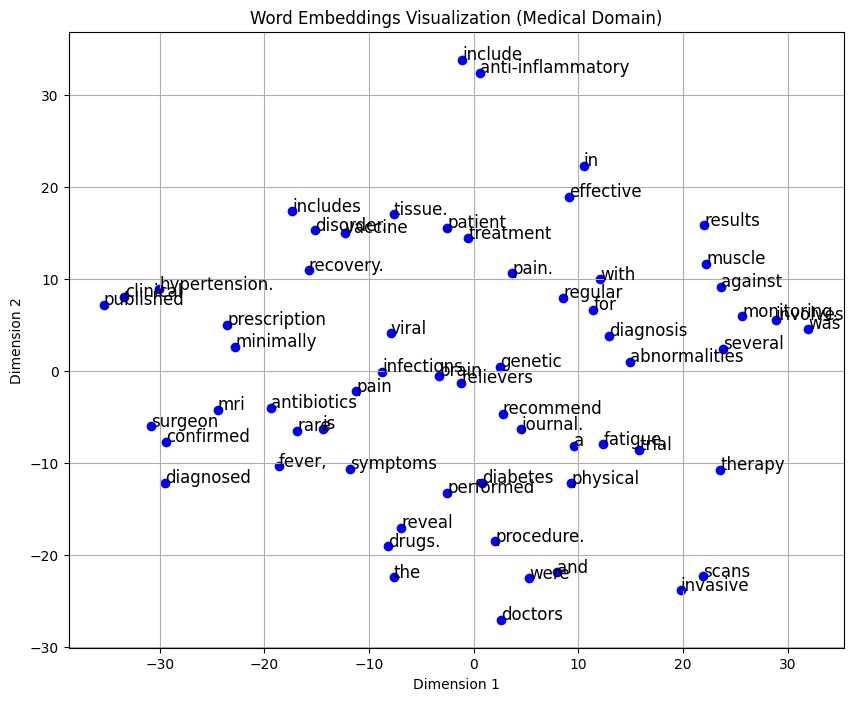

Words similar to 'treatment':
  patient (0.25)
  pain. (0.14)
  brain (0.12)
  against (0.11)
  muscle (0.11)
Words similar to 'vaccine':
  disorder. (0.20)
  tissue. (0.14)
  recovery. (0.12)
  therapy (0.10)
  doctors (0.09)


In [2]:
# pip install gensim matplotlib scikit-learn

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import numpy as np

m = Word2Vec([s.lower().split() for s in [
"The patient was diagnosed with diabetes and hypertension.",
"MRI scans reveal abnormalities in the brain tissue.",
"The treatment involves antibiotics and regular monitoring.",
"Symptoms include fever, fatigue, and muscle pain.",
"The vaccine is effective against several viral infections.",
"Doctors recommend physical therapy for recovery.",
"The clinical trial results were published in the journal.",
"The surgeon performed a minimally invasive procedure.",
"The prescription includes pain relievers and anti-inflammatory drugs.",
"The diagnosis confirmed a rare genetic disorder."
]], vector_size=100, window=5, min_count=1, workers=4, epochs=50)

w = list(m.wv.index_to_key)
p = TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(np.array([m.wv[x] for x in w]))

plt.figure(figsize=(10,8)); plt.scatter(p[:,0], p[:,1], color="blue")
for i,x in enumerate(w): plt.text(p[i,0]+0.02, p[i,1]+0.02, x, fontsize=12)
plt.title("Word Embeddings Visualization (Medical Domain)")
plt.xlabel("Dimension 1"); plt.ylabel("Dimension 2")
plt.grid(True); plt.show()

def f(x,n=5):
    try:
        print(f"Words similar to '{x}':")
        for a,b in m.wv.most_similar(x, topn=n): print(f"  {a} ({b:.2f})")
    except: print(f"'{x}' not found in vocabulary.")

f("treatment"); f("vaccine")